In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind

Text(0.5, 1.0, 'Regression Discontinuity: Training employee sales data')

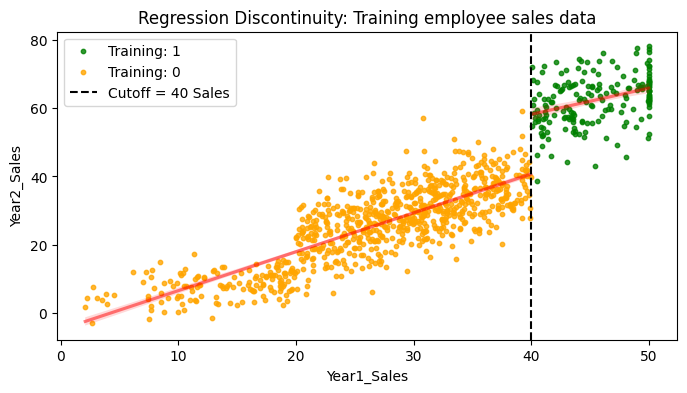

In [3]:
df = pd.read_csv("../""Data Sources""/rd_employee_sales_data.csv")

# 40 is the cuttoff for the sales training 
cutoff = 40
df.head()

fig = plt.subplots(figsize=(8,4))
sns.regplot(data=df[df['Training'] == 1], x='Year1_Sales'
            , y='Year2_Sales', color='green', label='Training: 1'
            ,line_kws={"color": "red", "alpha": 0.5} 
            ,scatter_kws={"color": "green", "s": 10})
sns.regplot(data=df[df['Training'] != 1], x='Year1_Sales'
            , y='Year2_Sales', color='orange', label='Training: 0'
           ,line_kws={"color": "red", "alpha": 0.5} 
            ,scatter_kws={"color": "orange", "s": 10})
plt.axvline(cutoff, color='black', linestyle='--', label="Cutoff = 40 Sales")
plt.legend()
plt.title("Regression Discontinuity: Training employee sales data")


## Naive regression model

In [4]:
formula = 'Year2_Sales ~ Training'

model = smf.ols(formula=formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     1797.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.96e-225
Time:                        13:14:40   Log-Likelihood:                -3783.7
No. Observations:                1000   AIC:                             7571.
Df Residuals:                     998   BIC:                             7581.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7360      0.374     68.849      0.0

## Controlling for the Running Variable

In [5]:
formula_whole_df = 'Year2_Sales ~ Year1_Sales + Training'
model_2 = smf.ols(formula_whole_df, df).fit()

print(model_2.summary())


                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     3084.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:14:40   Log-Likelihood:                -3312.5
No. Observations:                1000   AIC:                             6631.
Df Residuals:                     997   BIC:                             6646.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -4.4550      0.799     -5.576      

## Bandwidth Selection 

In [6]:
sales_interval = 10
df_subset = df[(df['Year1_Sales']>=cutoff - sales_interval)&(df['Year1_Sales']<=cutoff + sales_interval)]

formula_10_df = 'Year2_Sales ~ Year1_Sales + Training'
model_3 = smf.ols(formula_10_df, data=df_subset).fit()

print(model_3.summary())

''' By limiting sales  volume we increased training impact on second year sales'''



                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     1131.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          2.51e-189
Time:                        13:14:40   Log-Likelihood:                -1717.0
No. Observations:                 519   AIC:                             3440.
Df Residuals:                     516   BIC:                             3453.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.6052      3.297      1.700      

' By limiting sales  volume we increased training impact on second year sales'

In [7]:
trained = df_subset[df_subset['Training']==1]
baseline_sales = (trained['Year2_Sales'] - model_3.params['Training']).mean()

print(f"relative treatment efect from training is {model_3.params['Training']/baseline_sales: .2%}")



relative treatment efect from training is  44.50%


In [8]:
sales_interval = 5
df_subset_2 = df[(df['Year1_Sales']>=cutoff - sales_interval)&(df['Year1_Sales']<=cutoff + sales_interval)]

formula_5_df = 'Year2_Sales ~ Year1_Sales + Training'
model_4 = smf.ols(formula_5_df, data=df_subset_2).fit()

print(model_4.summary())


                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     344.1
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           4.94e-69
Time:                        13:14:40   Log-Likelihood:                -751.49
No. Observations:                 227   AIC:                             1509.
Df Residuals:                     224   BIC:                             1519.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.8004     11.595      0.500      

## RD Validation
Validating the Local Randomization Assumption

In [9]:
print(f"Share of part-time in training group {df.groupby('Training')['Part_Time'].agg('mean')}")

trained = df[df['Training']==1]['Part_Time']
not_trained = df[df['Training']==0]['Part_Time']

t_test, p_value = ttest_ind(trained, not_trained)
print(f"T-test for training group means: T-stat: {round(t_test,2)}, P-value: {p_value: .3f}")

Share of part-time in training group Training
0    0.28202
1    0.00000
Name: Part_Time, dtype: float64
T-test for training group means: T-stat: -8.58, P-value:  0.000


Part-time attribute has significant differenca acrose trained / not trained employees. That violate Local randomization assumption. But lest select subset within a bandwidth of plus or minus 10 around the cutoff.

In [10]:
cutoff = 40
subset = df[(df['Year1_Sales']>=cutoff-10)&(df['Year1_Sales']<=cutoff+10)].copy()
print(f"Share of part-time in training group {subset.groupby('Training')['Part_Time'].agg('mean')}")



Share of part-time in training group Training
0    0.0
1    0.0
Name: Part_Time, dtype: float64


We saw that 0% of employees were part-time in both the treated and untreated groups. This lack of difference supported our local randomization assumption.

## Placebo RD model

In [11]:
placebo_cutoff = 30 

placebo_subset = df[(df['Year1_Sales']>=placebo_cutoff-10)&(df['Year1_Sales']<=placebo_cutoff+10)].copy()
placebo_subset['placebo_training'] = np.where(placebo_subset['Year1_Sales']>=placebo_cutoff,1,0)

placebo_formula = "Year2_Sales ~ Year1_Sales + placebo_training"

placebo_model = smf.ols(formula=placebo_formula, data=placebo_subset).fit()
print(placebo_model.summary())


                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     189.7
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           8.02e-66
Time:                        13:14:40   Log-Likelihood:                -2196.9
No. Observations:                 664   AIC:                             4400.
Df Residuals:                     661   BIC:                             4413.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.5456      2.322  